In [1]:
#1.Download a sample sales dataset (for example, from Kaggle or use a small CSV you create) with columns 
#like product, category, date, and sales amount. Load it into a Pandas DataFrame and display the first 5 rows to verify the data.

import pandas as pd

# Create sample sales dataset
data = {
    "product": ["Shirt", "Jeans", "Shoes", "Watch", "Bag", 
                "Shirt", "Jeans", "Shoes", "Watch", "Bag"],
    "category": ["Clothing", "Clothing", "Footwear", "Accessories", "Accessories",
                 "Clothing", "Clothing", "Footwear", "Accessories", "Accessories"],
    "date": pd.date_range(start="2026-09-01", periods=10, freq="D"),
    "sales_amount": [1200, 1500, 1800, 900, 1100, 
                     1300, 1600, 1700, 950, 1250]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display first 5 rows
print(df.head())

  product     category       date  sales_amount
0   Shirt     Clothing 2026-09-01          1200
1   Jeans     Clothing 2026-09-02          1500
2   Shoes     Footwear 2026-09-03          1800
3   Watch  Accessories 2026-09-04           900
4     Bag  Accessories 2026-09-05          1100


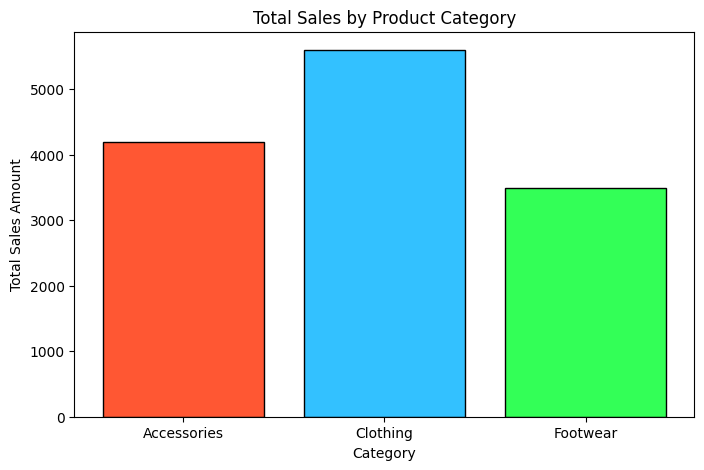

In [2]:
#2.Using Matplotlib, create a bar chart that shows total sales for each product category 
#(like 'Electronics', 'Clothing', 'Groceries'), similar to how Flipkart or Myntra might track category performance.

import matplotlib.pyplot as plt

# Group data by category and sum sales
category_sales = df.groupby("category")["sales_amount"].sum()

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values, 
        color=["#FF5733", "#33C1FF", "#33FF57", "#9D33FF"], edgecolor="black")

# Add labels and title
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales Amount")

plt.show()

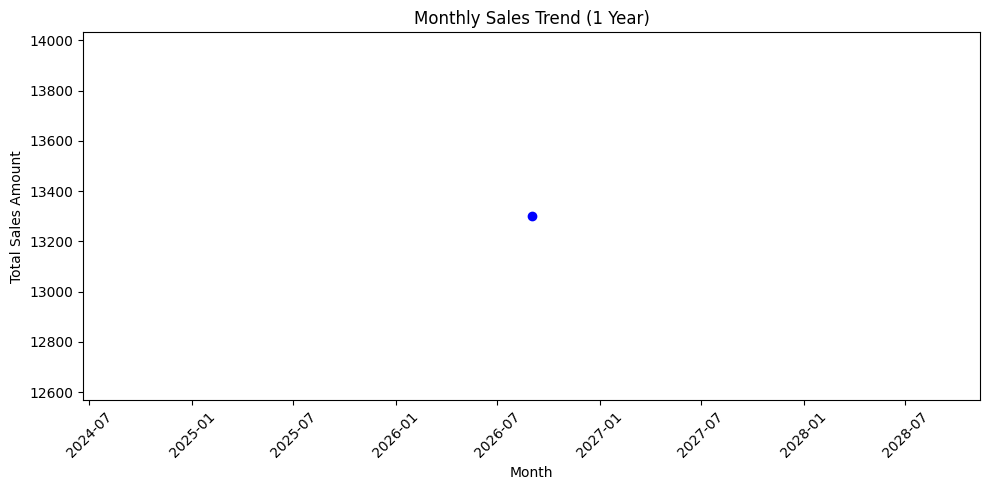

In [3]:
#3.Plot a line chart to visualize monthly sales trends 
#over a year, using the date column to group sales by month. Add a title and axis labels to make the chart presentation-ready.

# Group sales by month
monthly_sales = df.groupby(df["date"].dt.to_period("M"))["sales_amount"].sum()

# Convert PeriodIndex to datetime for plotting
months = monthly_sales.index.to_timestamp()

# Create line chart
plt.figure(figsize=(10,5))
plt.plot(months, monthly_sales.values, marker="o", color="blue", linewidth=2)

# Add title and axis labels
plt.title("Monthly Sales Trend (1 Year)")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")

# Format x-axis for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

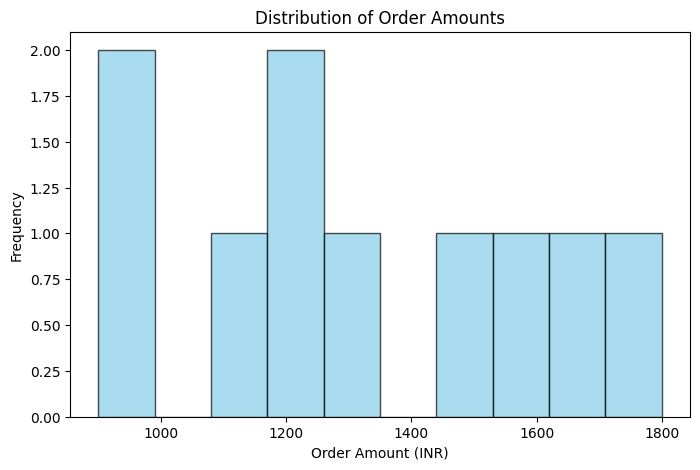

In [4]:
#4.Create a histogram to show the distribution of order amounts (sales values), highlighting how many small vs. large purchases happen — like 
#analyzing order size patterns on Zomato or Swiggy.<br><br><em><strong>Hint:</strong> Use plt.hist() and set bins to 10 for a clear distribution.</em>

# Extract sales values
sales_values = df["sales_amount"]

# Create histogram with 10 bins
plt.figure(figsize=(8,5))
plt.hist(sales_values, bins=10, color="skyblue", edgecolor="black", alpha=0.7)

# Add labels and title
plt.title("Distribution of Order Amounts")
plt.xlabel("Order Amount (INR)")
plt.ylabel("Frequency")

plt.show()

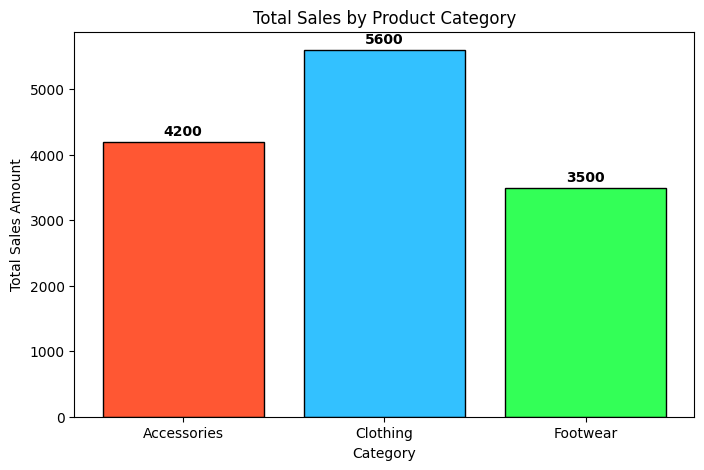

In [5]:
#5.Add value annotations to 
#your category bar chart to display the exact sales amount above each bar, then export the chart as a PNG image file named 'category_sales_kpi.png'.

# Group data by category and sum sales
category_sales = df.groupby("category")["sales_amount"].sum()

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(category_sales.index, category_sales.values, 
               color=["#FF5733", "#33C1FF", "#33FF57", "#9D33FF"], edgecolor="black")

# Add value annotations above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50,   # position above bar
             f"{height}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Add labels and title
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales Amount")

# Save chart as PNG with DPI=150
plt.savefig("category_sales_kpi.png", dpi=150)

plt.show()